#📌 Extracão

In [3]:
import pandas as pd
import numpy as np
import json

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

In [5]:
# PASSO 2 — TRANSFORMAÇÃO DOS DADOS

import pandas as pd
import numpy as np
import json
import requests # Needed to fetch data from the URL

# Re-fetch the raw JSON data from the URL to define 'data'
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
response = requests.get(url)
data = json.loads(response.text)

# Normalizar (flatten) o JSON
df = pd.json_normalize(data)

# Visualizar colunas
print(df.columns)

# Padronizar nomes das colunas (substituir "." por "_")
df.columns = df.columns.str.replace('.', '_', regex=False)

# Verificar valores ausentes
print(df.isnull().sum())

# Substituir valores vazios na coluna Churn por NaN
df['Churn'] = df['Churn'].replace('', np.nan)

# Converter coluna Total Charges para número
df['account_Charges_Total'] = pd.to_numeric(
    df['account_Charges_Total'],
    errors='coerce'
)

# Verificar duplicados
print("Duplicados:", df.duplicated().sum())

# Remover duplicados (se existirem)
df = df.drop_duplicates()

# Converter Churn para formato binário
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

# Conferir estrutura final
df.info()

# Visualizar primeiras linhas
df.head()

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')
customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
in

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#📊 Carga e análise

Análise Descritiva

In [6]:
# PASSO 3 — ANÁLISE DESCRITIVA

# Estatísticas gerais
print(df.describe())

# Estatísticas das principais variáveis
print(df[['customer_tenure',
          'account_Charges_Monthly',
          'account_Charges_Total']].describe())

# Média, mediana e desvio padrão da cobrança mensal
print("Média cobrança mensal:", df['account_Charges_Monthly'].mean())
print("Mediana cobrança mensal:", df['account_Charges_Monthly'].median())
print("Desvio padrão cobrança mensal:", df['account_Charges_Monthly'].std())

# Distribuição do churn
print("Distribuição de churn:")
print(df['Churn'].value_counts())

print("Porcentagem de churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Distribuição de variáveis categóricas
print("Tipos de contrato:")
print(df['account_Contract'].value_counts())

print("Tipos de internet:")
print(df['internet_InternetService'].value_counts())

print("Métodos de pagamento:")
print(df['account_PaymentMethod'].value_counts())

             Churn  customer_SeniorCitizen  customer_tenure  \
count  7043.000000             7267.000000      7267.000000   
mean      0.265370                0.162653        32.346498   
std       0.441561                0.369074        24.571773   
min       0.000000                0.000000         0.000000   
25%       0.000000                0.000000         9.000000   
50%       0.000000                0.000000        29.000000   
75%       1.000000                0.000000        55.000000   
max       1.000000                1.000000        72.000000   

       account_Charges_Monthly  account_Charges_Total  
count              7267.000000            7256.000000  
mean                 64.720098            2280.634213  
std                  30.129572            2268.632997  
min                  18.250000              18.800000  
25%                  35.425000             400.225000  
50%                  70.300000            1391.000000  
75%                  89.875000          

Distribuição da Evasão

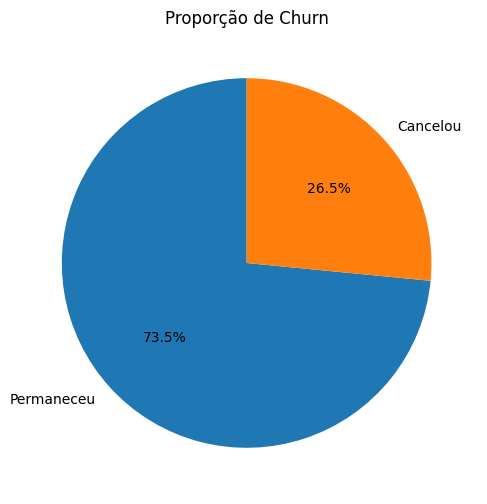

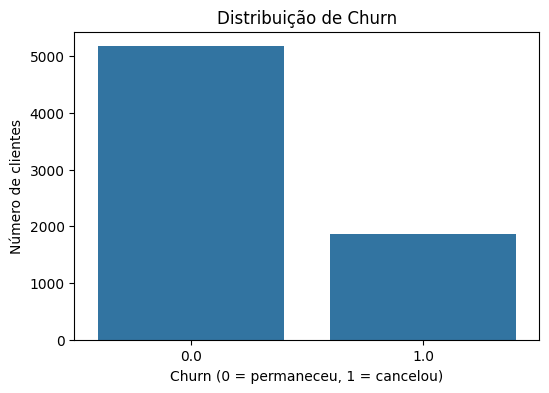

In [10]:
import matplotlib.pyplot as plt

df['Churn'].value_counts()

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=['Permaneceu','Cancelou'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proporção de Churn')
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title('Distribuição de Churn')
plt.xlabel('Churn (0 = permaneceu, 1 = cancelou)')
plt.ylabel('Número de clientes')

plt.show()

Contagem de Evasão por Variáveis Categóricas

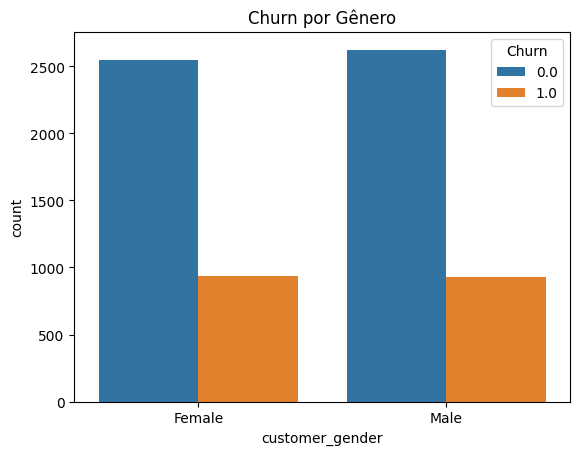

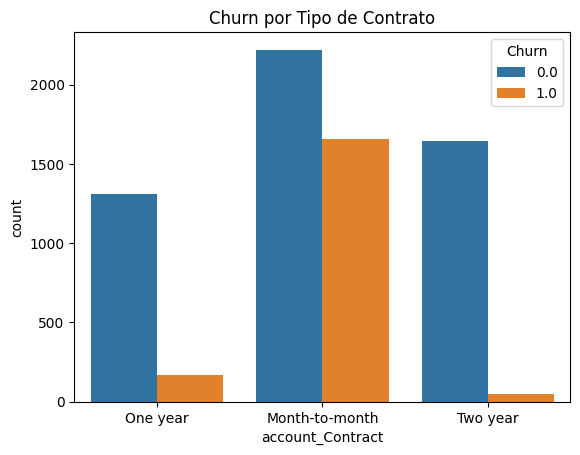

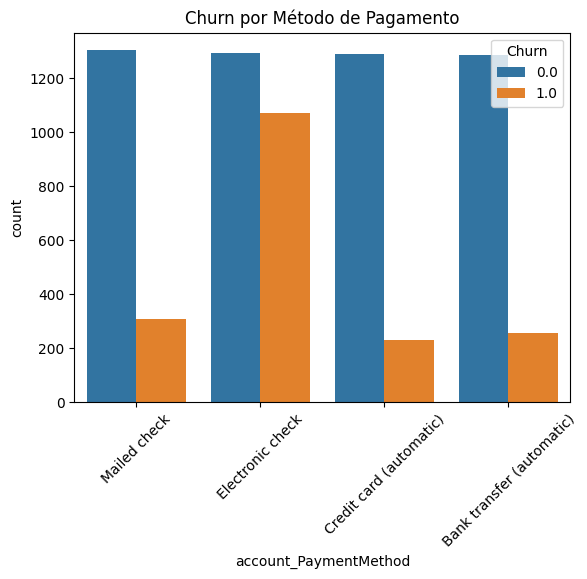

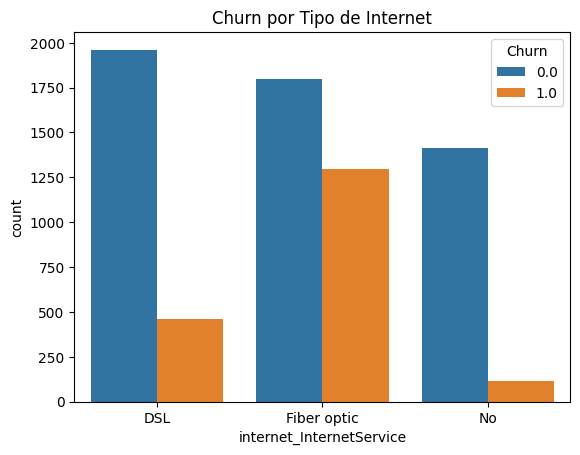

In [12]:
# Análise de churn por variáveis categóricas

import matplotlib.pyplot as plt
import seaborn as sns

# Churn por gênero
sns.countplot(x='customer_gender', hue='Churn', data=df)
plt.title('Churn por Gênero')
plt.show()

# Churn por tipo de contrato
sns.countplot(x='account_Contract', hue='Churn', data=df)
plt.title('Churn por Tipo de Contrato')
plt.show()

# Churn por método de pagamento
sns.countplot(x='account_PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title('Churn por Método de Pagamento')
plt.show()

# Churn por tipo de internet
sns.countplot(x='internet_InternetService', hue='Churn', data=df)
plt.title('Churn por Tipo de Internet')
plt.show()

Contagem de Evasão por Variáveis Numéricas

Estatísticas por grupo de churn:
      customer_tenure                                                     \
                count       mean        std  min   25%   50%   75%   max   
Churn                                                                      
0.0            5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
1.0            1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      account_Charges_Monthly             ...                \
                        count       mean  ...   75%     max   
Churn                                     ...                 
0.0                    5174.0  61.265124  ...  88.4  118.75   
1.0                    1869.0  74.441332  ...  94.2  118.35   

      account_Charges_Total                                            \
                      count         mean          std    min      25%   
Churn                                                                   
0.0                  5163.0  2555.344141  2329.4569

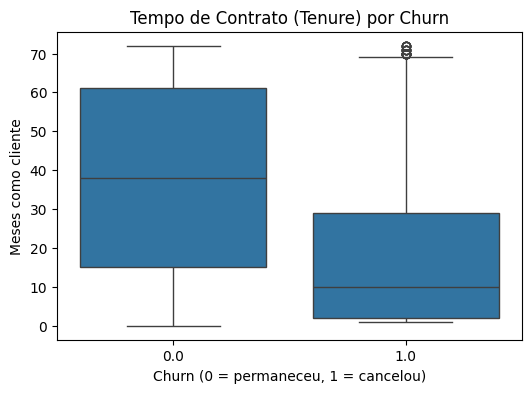

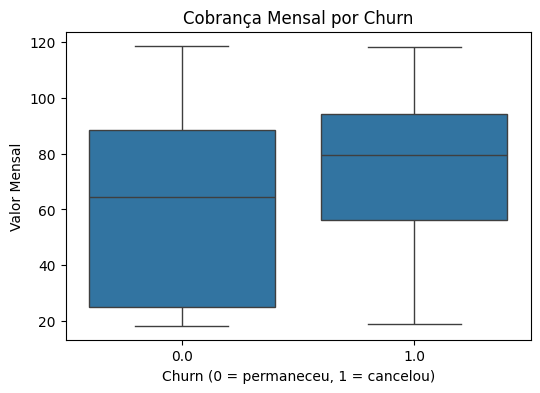

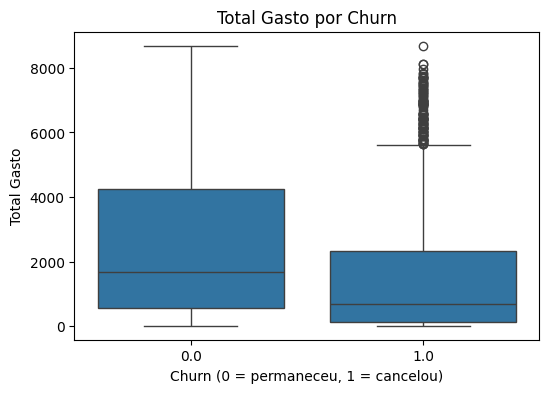

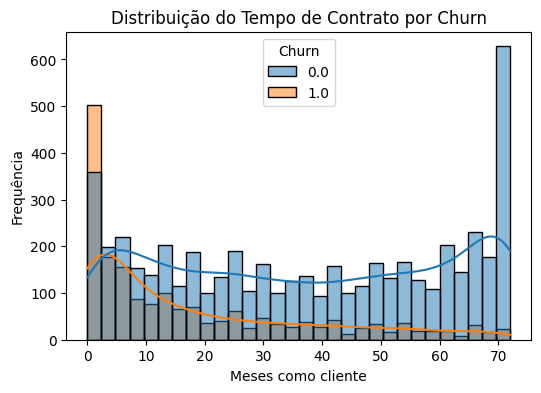

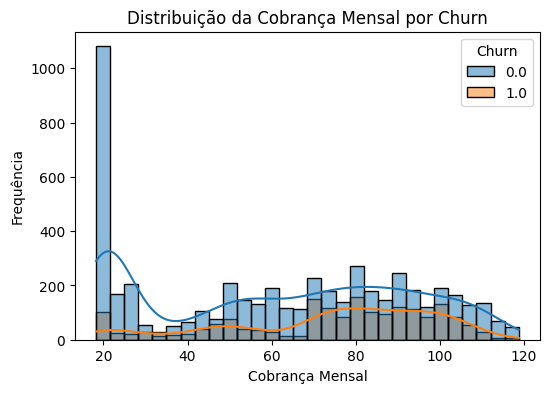

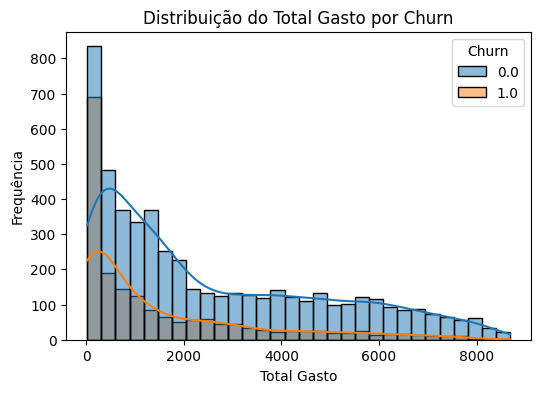

In [13]:
# PASSO 3 — ANÁLISE DE VARIÁVEIS NUMÉRICAS RELACIONADAS AO CHURN

import matplotlib.pyplot as plt
import seaborn as sns

# Estatísticas descritivas por churn
print("Estatísticas por grupo de churn:")
print(df.groupby('Churn')[['customer_tenure',
                           'account_Charges_Monthly',
                           'account_Charges_Total']].describe())

# Boxplot: tempo de contrato vs churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title('Tempo de Contrato (Tenure) por Churn')
plt.xlabel('Churn (0 = permaneceu, 1 = cancelou)')
plt.ylabel('Meses como cliente')
plt.show()

# Boxplot: cobrança mensal vs churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df)
plt.title('Cobrança Mensal por Churn')
plt.xlabel('Churn (0 = permaneceu, 1 = cancelou)')
plt.ylabel('Valor Mensal')
plt.show()

# Boxplot: total gasto vs churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account_Charges_Total', data=df)
plt.title('Total Gasto por Churn')
plt.xlabel('Churn (0 = permaneceu, 1 = cancelou)')
plt.ylabel('Total Gasto')
plt.show()

# Histogramas para visualizar distribuição das variáveis numéricas
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='customer_tenure', hue='Churn', bins=30, kde=True)
plt.title('Distribuição do Tempo de Contrato por Churn')
plt.xlabel('Meses como cliente')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='account_Charges_Monthly', hue='Churn', bins=30, kde=True)
plt.title('Distribuição da Cobrança Mensal por Churn')
plt.xlabel('Cobrança Mensal')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='account_Charges_Total', hue='Churn', bins=30, kde=True)
plt.title('Distribuição do Total Gasto por Churn')
plt.xlabel('Total Gasto')
plt.ylabel('Frequência')
plt.show()

Análise de Correlação entre Variáveis

/tmp/ipykernel_482/394115014.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


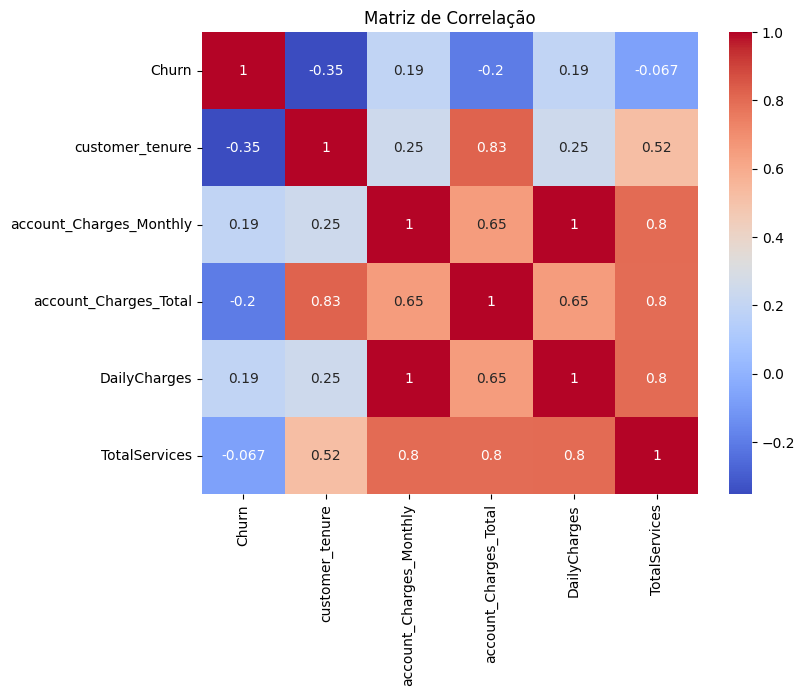

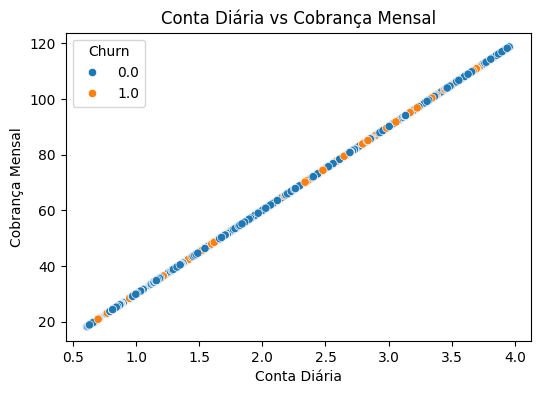

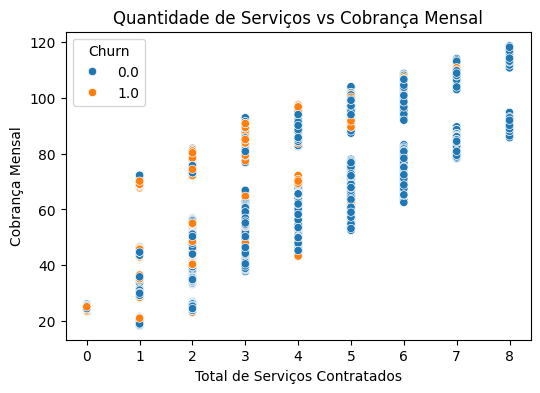

In [14]:
# ANÁLISE EXTRA (OPCIONAL) — CORRELAÇÃO ENTRE VARIÁVEIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criar variável de conta diária média
df['DailyCharges'] = df['account_Charges_Monthly'] / 30

# 2. Criar variável com quantidade de serviços contratados
servicos = [
    'phone_PhoneService',
    'phone_MultipleLines',
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport',
    'internet_StreamingTV',
    'internet_StreamingMovies'
]

for col in servicos:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'No phone service': 0,
        'No internet service': 0
    })

df['TotalServices'] = df[servicos].sum(axis=1)

# 3. Matriz de correlação
corr = df[['Churn',
           'customer_tenure',
           'account_Charges_Monthly',
           'account_Charges_Total',
           'DailyCharges',
           'TotalServices']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

# 4. Gráfico de dispersão: conta diária vs churn
plt.figure(figsize=(6,4))
sns.scatterplot(x='DailyCharges', y='account_Charges_Monthly', hue='Churn', data=df)
plt.title('Conta Diária vs Cobrança Mensal')
plt.xlabel('Conta Diária')
plt.ylabel('Cobrança Mensal')
plt.show()

# 5. Gráfico de dispersão: total de serviços vs churn
plt.figure(figsize=(6,4))
sns.scatterplot(x='TotalServices', y='account_Charges_Monthly', hue='Churn', data=df)
plt.title('Quantidade de Serviços vs Cobrança Mensal')
plt.xlabel('Total de Serviços Contratados')
plt.ylabel('Cobrança Mensal')
plt.show()

#📄Relatorio Final

## 1. Introdução

O objetivo desta análise foi investigar os fatores associados à evasão de clientes (churn) na Telecom X. Para isso, foram realizadas etapas de extração, transformação e análise exploratória dos dados, buscando identificar padrões que expliquem o cancelamento de serviços.

Com base nas análises descritivas e nas visualizações geradas, foi possível identificar características e comportamentos associados a uma maior probabilidade de evasão.

---

# 2. Principais resultados da análise

## 📉 Distribuição geral de churn

A análise inicial mostrou que a maioria dos clientes permanece na empresa, porém uma parcela relevante cancela o serviço.

Essa taxa de evasão é significativa e representa um desafio para a retenção de clientes, indicando a necessidade de estratégias focadas na fidelização.

---

## 📄 Tipo de contrato

Um dos fatores mais relevantes identificados foi o **tipo de contrato**.

Clientes com **contrato mensal (Month-to-month)** apresentam uma taxa de evasão muito maior do que clientes com contratos anuais ou de dois anos.

Isso sugere que contratos de longo prazo funcionam como um importante mecanismo de retenção.

### Insight

Clientes sem compromisso de longo prazo possuem maior probabilidade de cancelar o serviço.

### Possível ação estratégica

Criar incentivos para migração para contratos anuais ou de dois anos, como:

- descontos
- benefícios adicionais
- programas de fidelidade

---

## 💳 Método de pagamento

Foi observado que determinados métodos de pagamento apresentam maior incidência de churn, especialmente **pagamentos via cheque eletrônico**.

Métodos automáticos como cartão de crédito ou transferência bancária tendem a apresentar menor evasão.

### Insight

Clientes que utilizam pagamentos automáticos tendem a permanecer mais tempo na empresa.

### Possível ação estratégica

Incentivar métodos de pagamento automáticos oferecendo:

- descontos
- cashback
- benefícios exclusivos

---

## 🌐 Tipo de serviço de internet

Clientes que utilizam **internet de fibra óptica** apresentam maior taxa de evasão em comparação com outros tipos de serviço.

Isso pode estar relacionado a fatores como:

- maior preço do serviço
- concorrência mais forte nesse segmento
- expectativa mais alta dos clientes

### Insight

Serviços mais caros ou com maior concorrência podem ter maior risco de churn.

### Possível ação estratégica

Investigar:

- qualidade do serviço
- satisfação dos clientes
- competitividade de preços

---

## ⏱ Tempo como cliente (tenure)

A análise mostrou que clientes com **menor tempo de permanência na empresa** apresentam maior probabilidade de cancelar o serviço.

Clientes que permanecem por mais tempo tendem a continuar com a empresa.

### Insight

Os primeiros meses de relacionamento com o cliente são críticos para retenção.

### Possível ação estratégica

Criar estratégias de retenção para novos clientes, como:

- acompanhamento nos primeiros meses
- suporte prioritário
- programas de boas-vindas

---

## 💰 Cobrança mensal e valor total gasto

Foi observado que clientes com **cobranças mensais mais altas** tendem a apresentar maior taxa de evasão.

Por outro lado, clientes que permanecem por mais tempo acabam acumulando um valor total gasto maior, indicando fidelização.

### Insight

Preços mais elevados podem aumentar o risco de cancelamento.

### Possível ação estratégica

Avaliar:

- competitividade dos planos
- percepção de valor do serviço
- estrutura de preços

---

## 🔗 Correlação entre variáveis

A análise de correlação indicou relações entre algumas variáveis importantes, como:

- tempo de contrato
- valor mensal da cobrança
- quantidade de serviços contratados

Clientes que contratam mais serviços tendem a apresentar maior valor mensal, o que pode influenciar na probabilidade de churn dependendo da percepção de custo-benefício.

---

# 📌 Conclusão

A análise exploratória permitiu identificar fatores importantes associados à evasão de clientes na Telecom X.

Os principais fatores relacionados ao churn são:

- contratos mensais
- menor tempo como cliente
- cobranças mensais mais altas
- determinados métodos de pagamento
- tipo de serviço contratado

Esses insights podem ajudar a empresa a desenvolver estratégias mais eficazes de retenção, como incentivar contratos de longo prazo, melhorar a experiência de novos clientes e revisar políticas de preços e serviços.